# Reinforcement Learning Concepts: GridWorld

**Solved Examples Notebook -- Week 1**

This notebook is completely self-contained and is *not* about the walking robot project.  
It exists to teach you the core ideas of RL in a simple setting before you apply them to the robot.

**You will learn:**
- What a Markov Decision Process (MDP) is
- How to represent a simple grid environment
- How Value Iteration solves an MDP
- What a policy looks like in practice
- How Q-Learning learns without knowing the environment model

---
**All code is already written and explained. Read each section, run the cell, and make sure you understand the output before moving on.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
import random

# Make outputs reproducible
np.random.seed(42)
random.seed(42)

print('Libraries loaded.')

Libraries loaded.


---
## Part 1: The GridWorld Environment

GridWorld is a classic RL teaching environment.  The world is a 2D grid.  
The agent starts in one cell and must reach a goal cell while avoiding walls.

### Our setup

```
 0  1  2  3  4
 5  6  7  8  9
10 11 12 13 14
15 16 17 18 19
20 21 22 23 24
```

- Grid size: 5 x 5  (25 cells, numbered 0 to 24)
- **Goal:** cell 24 (bottom-right corner).  Reward = +10.
- **Pit (bad state):** cell 17.  Reward = -10, episode ends.
- **All other steps:** reward = -1 (small cost to encourage short paths).
- After reaching the goal or falling in the pit, the episode ends.

### Actions
0 = Up, 1 = Down, 2 = Left, 3 = Right  
Moving into a wall leaves the agent in the same cell.

### Transition model
The environment is deterministic: action always succeeds.

In [2]:
# ---------- GridWorld definition ----------

GRID_SIZE = 5
N_STATES  = GRID_SIZE * GRID_SIZE          # 25 states
N_ACTIONS = 4                              # up, down, left, right
GOAL_STATE = 24
PIT_STATE  = 17
GAMMA = 0.9                                # discount factor

# Map action index to (row_delta, col_delta)
ACTIONS = {
    0: (-1,  0),   # up
    1: ( 1,  0),   # down
    2: ( 0, -1),   # left
    3: ( 0,  1),   # right
}
ACTION_NAMES = ['Up', 'Down', 'Left', 'Right']


def state_to_rc(state):
    """Convert a state index (0-24) into (row, col)."""
    return state // GRID_SIZE, state % GRID_SIZE


def rc_to_state(row, col):
    """Convert (row, col) into a state index."""
    return row * GRID_SIZE + col


def step(state, action):
    """
    Take one step in the grid.
    Returns: (next_state, reward, done)
    """
    # Terminal states: no transitions out
    if state in (GOAL_STATE, PIT_STATE):
        return state, 0.0, True

    r, c = state_to_rc(state)
    dr, dc = ACTIONS[action]
    nr, nc = r + dr, c + dc

    # Clamp to grid boundaries (wall = stay in place)
    nr = np.clip(nr, 0, GRID_SIZE - 1)
    nc = np.clip(nc, 0, GRID_SIZE - 1)

    next_state = rc_to_state(nr, nc)

    if next_state == GOAL_STATE:
        return next_state, +10.0, True
    elif next_state == PIT_STATE:
        return next_state, -10.0, True
    else:
        return next_state, -1.0, False


# Quick sanity check
ns, r, done = step(23, 3)   # state 23 = row 4, col 3;  action Right -> col 4 -> state 24
print(f'From state 23, action Right -> next_state={ns}, reward={r}, done={done}')
assert ns == 24 and r == 10.0 and done

From state 23, action Right -> next_state=24, reward=10.0, done=True


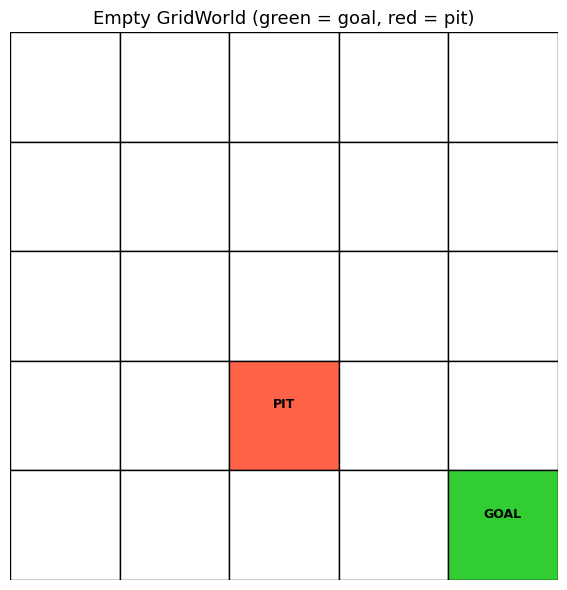

In [3]:
def plot_grid(values=None, policy=None, title='GridWorld'):
    """
    Visualise the grid.  Optionally overlay value function (as colour + number)
    and policy (as arrows).
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    # Draw cells
    for s in range(N_STATES):
        r, c = state_to_rc(s)
        y = GRID_SIZE - 1 - r    # flip so row 0 is at the top visually

        color = 'white'
        if s == GOAL_STATE:
            color = 'limegreen'
        elif s == PIT_STATE:
            color = 'tomato'
        elif values is not None:
            # Normalise value to [0, 1] for colour
            v_min, v_max = values.min(), values.max()
            norm_v = (values[s] - v_min) / (v_max - v_min + 1e-8)
            color = plt.cm.Blues(0.2 + 0.7 * norm_v)

        rect = mpatches.FancyBboxPatch(
            (c, y), 1, 1,
            boxstyle='square,pad=0',
            linewidth=1, edgecolor='black',
            facecolor=color
        )
        ax.add_patch(rect)

        # Value label
        label = ''
        if s == GOAL_STATE:
            label = 'GOAL'
        elif s == PIT_STATE:
            label = 'PIT'
        elif values is not None:
            label = f'{values[s]:.1f}'
        ax.text(c + 0.5, y + 0.6, label, ha='center', va='center',
                fontsize=9, fontweight='bold')

        # Policy arrow
        if policy is not None and s not in (GOAL_STATE, PIT_STATE):
            a = policy[s]
            dr, dc = ACTIONS[a]
            ax.annotate('',
                xy=(c + 0.5 + dc*0.3, y + 0.5 - dr*0.3),
                xytext=(c + 0.5, y + 0.5),
                arrowprops=dict(arrowstyle='->', color='navy', lw=1.5))

    ax.set_xlim(0, GRID_SIZE)
    ax.set_ylim(0, GRID_SIZE)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=13)
    plt.tight_layout()
    plt.show()


# Draw the blank grid to make sure it looks right
plot_grid(title='Empty GridWorld (green = goal, red = pit)')

---
## Part 2: Value Iteration

Value Iteration is a **dynamic programming** method that solves an MDP exactly,  
provided we know the transition model $P(s' | s, a)$ and reward $R(s, a, s')$.  

### The Bellman optimality equation

The optimal value of state $s$ is:
$$
V^*(s) = \max_a \sum_{s'} P(s'|s,a) \left[ R(s,a,s') + \gamma V^*(s') \right]
$$

Since our environment is **deterministic**, this simplifies to:
$$
V^*(s) = \max_a \left[ R(s, a, s') + \gamma V^*(s') \right]
$$

### The algorithm
1. Start with $V(s) = 0$ for all $s$.
2. Repeat: update every state using the Bellman equation.
3. Stop when the maximum change across all states is smaller than a threshold $\theta$.
4. Extract the **greedy policy**: for each state, pick the action that gives the highest value.

In [4]:
def value_iteration(gamma=GAMMA, theta=1e-6):
    """
    Solve the GridWorld MDP using Value Iteration.
    
    Returns:
        V      -- optimal value function, shape (N_STATES,)
        policy -- optimal policy, shape (N_STATES,)  (each entry is an action index)
        history -- list of V vectors at each sweep (for visualisation)
    """
    V = np.zeros(N_STATES)
    history = [V.copy()]
    n_sweeps = 0

    while True:
        delta = 0.0
        V_new = V.copy()

        for s in range(N_STATES):
            # Terminal states have fixed value 0 after episode ends
            if s in (GOAL_STATE, PIT_STATE):
                continue

            action_values = []
            for a in range(N_ACTIONS):
                next_s, reward, _ = step(s, a)
                # Bellman backup
                q = reward + gamma * V[next_s]
                action_values.append(q)

            V_new[s] = max(action_values)
            delta = max(delta, abs(V_new[s] - V[s]))

        V = V_new
        n_sweeps += 1
        history.append(V.copy())

        if delta < theta:
            break

    print(f'Value Iteration converged in {n_sweeps} sweeps.')

    # Extract greedy policy
    policy = np.zeros(N_STATES, dtype=int)
    for s in range(N_STATES):
        if s in (GOAL_STATE, PIT_STATE):
            continue
        action_values = []
        for a in range(N_ACTIONS):
            next_s, reward, _ = step(s, a)
            action_values.append(reward + gamma * V[next_s])
        policy[s] = np.argmax(action_values)

    return V, policy, history


V_star, pi_star, vi_history = value_iteration()

print('\nOptimal values V*(s) reshaped as grid:')
print(np.round(V_star.reshape(GRID_SIZE, GRID_SIZE), 2))

Value Iteration converged in 9 sweeps.

Optimal values V*(s) reshaped as grid:
[[-0.43  0.63  1.81  3.12  4.58]
 [ 0.63  1.81  3.12  4.58  6.2 ]
 [ 1.81  3.12  4.58  6.2   8.  ]
 [ 3.12  4.58  0.    8.   10.  ]
 [ 4.58  6.2   8.   10.    0.  ]]


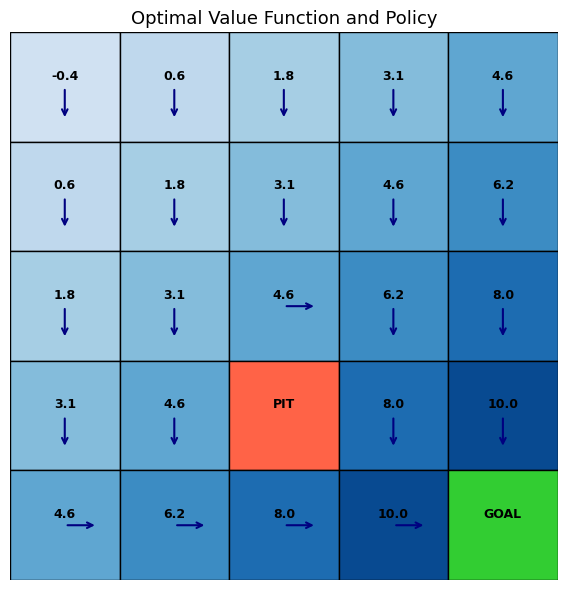

In [5]:
# Visualise the optimal value function + policy
plot_grid(values=V_star, policy=pi_star,
          title='Optimal Value Function and Policy')

**What do you see?**

- The goal cell (green) has the highest value: $V^*(24) = 0$ because the episode ends immediately after.
- States close to the goal have high values. States near the pit have low values.
- The arrows (policy) always point toward the goal while staying away from the pit.

This is the **optimal policy**: following it gets the agent to the goal as quickly as possible.

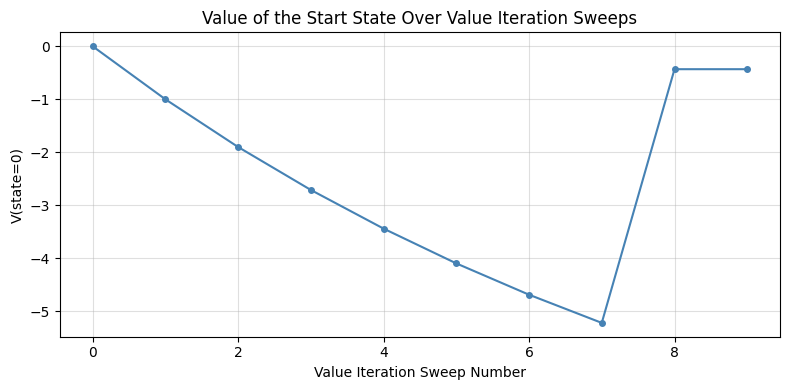

Final V(start) = -0.4341


In [6]:
# Plot how the value of the start state (state 0) changes over sweeps
v0_over_time = [h[0] for h in vi_history]

plt.figure(figsize=(8, 4))
plt.plot(v0_over_time, marker='o', markersize=4, linewidth=1.5, color='steelblue')
plt.xlabel('Value Iteration Sweep Number')
plt.ylabel('V(state=0)')
plt.title('Value of the Start State Over Value Iteration Sweeps')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f'Final V(start) = {v0_over_time[-1]:.4f}')

**Key observation:** The value of the start state starts at zero (we have no information) and increases with each sweep as the Bellman updates propagate information backward from the goal.

This is called **backward induction**: the algorithm first learns the value of states near the goal and then uses those values to compute the values of earlier states.

---
## Part 3: Following the Optimal Policy

Now let us simulate an episode where the agent follows the optimal policy from the start state.

In [7]:
def run_episode(policy, start_state=0, max_steps=50):
    """Run one episode following the given policy. Returns the trajectory."""
    state = start_state
    trajectory = [state]
    total_reward = 0.0

    for step_num in range(max_steps):
        action = policy[state]
        next_state, reward, done = step(state, action)
        total_reward += reward
        trajectory.append(next_state)
        print(f'  Step {step_num+1}: state {state} ({state_to_rc(state)}) '
              f'-> action {ACTION_NAMES[action]} '
              f'-> state {next_state} ({state_to_rc(next_state)}) '
              f'reward={reward}')
        state = next_state
        if done:
            break

    print(f'\nTotal reward: {total_reward}')
    return trajectory, total_reward


print('=== Optimal policy episode ===')
traj, total_r = run_episode(pi_star, start_state=0)

=== Optimal policy episode ===
  Step 1: state 0 ((0, 0)) -> action Down -> state 5 ((np.int64(1), np.int64(0))) reward=-1.0
  Step 2: state 5 ((np.int64(1), np.int64(0))) -> action Down -> state 10 ((np.int64(2), np.int64(0))) reward=-1.0
  Step 3: state 10 ((np.int64(2), np.int64(0))) -> action Down -> state 15 ((np.int64(3), np.int64(0))) reward=-1.0
  Step 4: state 15 ((np.int64(3), np.int64(0))) -> action Down -> state 20 ((np.int64(4), np.int64(0))) reward=-1.0
  Step 5: state 20 ((np.int64(4), np.int64(0))) -> action Right -> state 21 ((np.int64(4), np.int64(1))) reward=-1.0
  Step 6: state 21 ((np.int64(4), np.int64(1))) -> action Right -> state 22 ((np.int64(4), np.int64(2))) reward=-1.0
  Step 7: state 22 ((np.int64(4), np.int64(2))) -> action Right -> state 23 ((np.int64(4), np.int64(3))) reward=-1.0
  Step 8: state 23 ((np.int64(4), np.int64(3))) -> action Right -> state 24 ((np.int64(4), np.int64(4))) reward=10.0

Total reward: 3.0


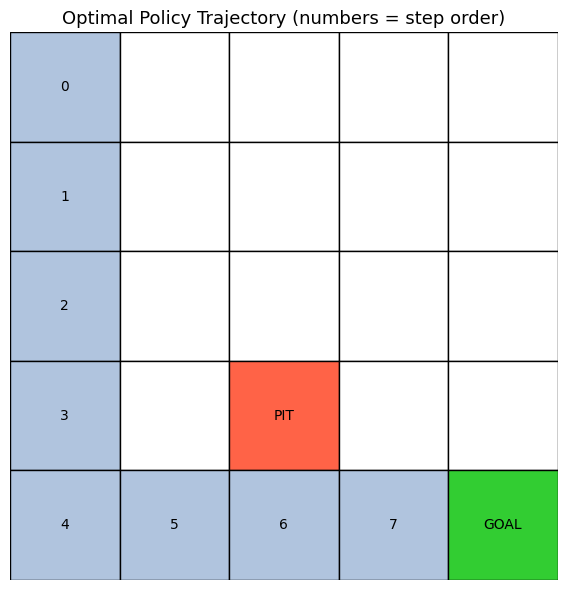

In [8]:
# Visualise the trajectory on the grid
def plot_trajectory(trajectory, title='Agent Trajectory'):
    fig, ax = plt.subplots(figsize=(6, 6))

    for s in range(N_STATES):
        r, c = state_to_rc(s)
        y = GRID_SIZE - 1 - r
        color = 'white'
        if s == GOAL_STATE:   color = 'limegreen'
        elif s == PIT_STATE:  color = 'tomato'
        elif s in trajectory: color = 'lightsteelblue'
        rect = mpatches.FancyBboxPatch(
            (c, y), 1, 1, boxstyle='square,pad=0',
            linewidth=1, edgecolor='black', facecolor=color)
        ax.add_patch(rect)
        label = ''
        if s == GOAL_STATE:   label = 'GOAL'
        elif s == PIT_STATE:  label = 'PIT'
        elif s in trajectory: label = str(trajectory.index(s))
        ax.text(c + 0.5, y + 0.5, label, ha='center', va='center', fontsize=10)

    ax.set_xlim(0, GRID_SIZE)
    ax.set_ylim(0, GRID_SIZE)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=13)
    plt.tight_layout()
    plt.show()


plot_trajectory(traj, title='Optimal Policy Trajectory (numbers = step order)')

---
## Part 4: Q-Learning (Model-Free RL)

Value Iteration requires knowing the full transition model $P(s'|s,a)$.  
In most real problems (including our walking robot), we do **not** know the model.  
We can only observe the transitions that actually happen.

**Q-Learning** is a model-free algorithm that learns the action-value function $Q(s,a)$  
directly from experience.

### The Q-Learning update rule

After observing transition $(s, a, r, s')$:
$$
Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]
$$

- $\alpha$ is the learning rate.
- The term $r + \gamma \max_{a'} Q(s', a')$ is the **TD target**: our current best estimate of what $Q(s,a)$ should be.
- We move $Q(s,a)$ a fraction $\alpha$ toward the TD target.

### Exploration with epsilon-greedy

To discover good actions, the agent sometimes takes random actions:
- With probability $\varepsilon$: take a **random** action (exploration).
- With probability $1 - \varepsilon$: take the action with the highest $Q$ value (exploitation).

We decrease $\varepsilon$ over time so the agent explores less as it learns.

In [9]:
def q_learning(
    n_episodes=3000,
    alpha=0.1,
    gamma=GAMMA,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.999,
):
    """Train a Q-table on GridWorld using Q-Learning."""
    # Q-table: Q[state, action]
    Q = np.zeros((N_STATES, N_ACTIONS))
    epsilon = epsilon_start
    episode_rewards = []

    for ep in range(n_episodes):
        state = 0          # always start at state 0
        total_reward = 0.0

        for _ in range(200):   # max steps per episode
            # Epsilon-greedy action selection
            if random.random() < epsilon:
                action = random.randint(0, N_ACTIONS - 1)
            else:
                action = int(np.argmax(Q[state]))

            next_state, reward, done = step(state, action)
            total_reward += reward

            # Q-Learning update
            td_target = reward + gamma * np.max(Q[next_state])
            td_error  = td_target - Q[state, action]
            Q[state, action] += alpha * td_error

            state = next_state
            if done:
                break

        episode_rewards.append(total_reward)
        epsilon = max(epsilon_end, epsilon * epsilon_decay)

    return Q, episode_rewards


Q_table, rewards = q_learning(n_episodes=3000)

# Extract greedy policy from Q-table
q_policy = np.argmax(Q_table, axis=1)

print('Q-table shape:', Q_table.shape)
print('\nGreedy policy from Q-table (action indices):')
print(q_policy.reshape(GRID_SIZE, GRID_SIZE))
print('\nOptimal policy (from Value Iteration) for comparison:')
print(pi_star.reshape(GRID_SIZE, GRID_SIZE))

Q-table shape: (25, 4)

Greedy policy from Q-table (action indices):
[[1 1 1 1 1]
 [3 1 1 1 1]
 [3 1 3 1 1]
 [3 1 0 1 1]
 [3 3 3 3 0]]

Optimal policy (from Value Iteration) for comparison:
[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 3 1 1]
 [1 1 0 1 1]
 [3 3 3 3 0]]


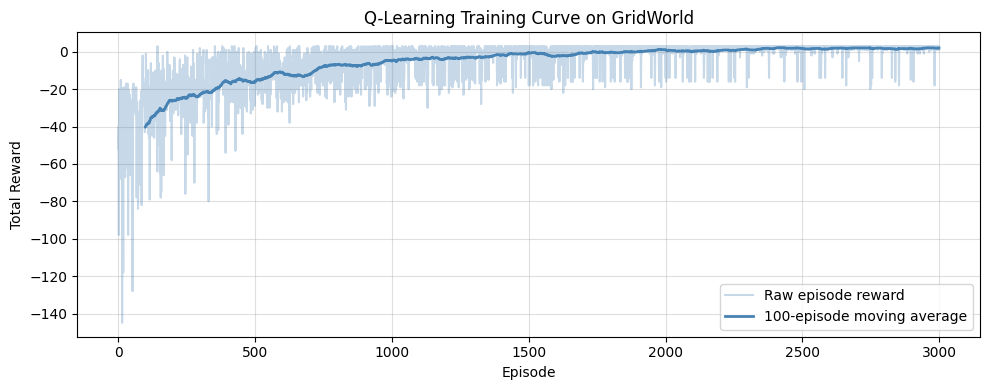

Average reward over last 200 episodes: 1.91


In [10]:
# Smooth rewards with a moving average for a cleaner plot
window = 100
smoothed = np.convolve(rewards, np.ones(window) / window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(rewards, alpha=0.3, color='steelblue', label='Raw episode reward')
plt.plot(range(window - 1, len(rewards)), smoothed,
         color='steelblue', linewidth=2, label=f'{window}-episode moving average')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning Training Curve on GridWorld')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f'Average reward over last 200 episodes: {np.mean(rewards[-200:]):.2f}')

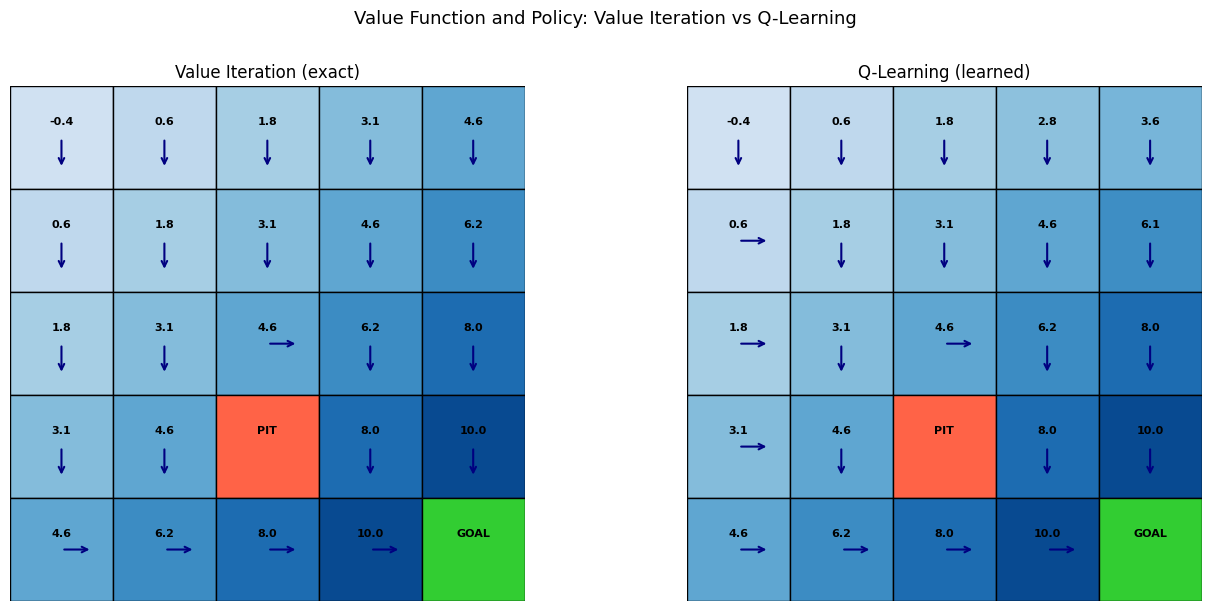

In [11]:
# Extract V from Q-table:  V(s) = max_a Q(s, a)
V_q = np.max(Q_table, axis=1)

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (V, pol, title) in zip(
    axes,
    [(V_star, pi_star, 'Value Iteration (exact)'),
     (V_q,   q_policy, 'Q-Learning (learned)')]
):
    plt.sca(ax)
    for s in range(N_STATES):
        r, c = state_to_rc(s)
        y = GRID_SIZE - 1 - r
        color = 'limegreen' if s == GOAL_STATE else ('tomato' if s == PIT_STATE else 'white')
        if s not in (GOAL_STATE, PIT_STATE):
            v_min, v_max = V.min(), V.max()
            nv = (V[s] - v_min) / (v_max - v_min + 1e-8)
            color = plt.cm.Blues(0.2 + 0.7 * nv)
        rect = mpatches.FancyBboxPatch((c, y), 1, 1,
                                        boxstyle='square,pad=0',
                                        linewidth=1, edgecolor='black',
                                        facecolor=color)
        ax.add_patch(rect)
        lbl = 'GOAL' if s == GOAL_STATE else ('PIT' if s == PIT_STATE else f'{V[s]:.1f}')
        ax.text(c+0.5, y+0.65, lbl, ha='center', va='center', fontsize=8, fontweight='bold')
        if s not in (GOAL_STATE, PIT_STATE):
            dr, dc = ACTIONS[pol[s]]
            ax.annotate('', xy=(c+0.5+dc*0.3, y+0.5-dr*0.3),
                        xytext=(c+0.5, y+0.5),
                        arrowprops=dict(arrowstyle='->', color='navy', lw=1.5))
    ax.set_xlim(0, GRID_SIZE)
    ax.set_ylim(0, GRID_SIZE)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=12)

plt.suptitle('Value Function and Policy: Value Iteration vs Q-Learning', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**The two policies should be very similar (or identical in most cells).**  
The key difference is *how* they were computed:

| Method | Needs model? | How it learns |
|--------|-------------|---------------|
| Value Iteration | Yes | Computes exact Bellman backup using $P(s'|s,a)$ |
| Q-Learning | No | Updates from actual experience $(s, a, r, s')$ |

Our walking robot uses **PPO**, which is also model-free. It learns entirely from experience, just like Q-Learning, but uses neural networks instead of a table and a more sophisticated update rule.

---
## Part 5: Reflection Questions

Answer these in your own words before moving to the next notebook.

**Q1.** In the GridWorld, what happens to the policy near the pit (state 17)?  
Why do some adjacent cells point away from the pit even though the goal is on the other side?

**Q2.** What would happen to the optimal policy if you set gamma = 0?  
What about gamma = 1? (Hint: think about what $G_t$ becomes in each case.)

**Q3.** Q-Learning uses epsilon-greedy exploration. Why do we need exploration at all?  
What would happen if epsilon = 0 from the start?

**Q4.** In our walking robot, the state space has 22 dimensions and actions are continuous.  
We cannot use a Q-table. Why not? (Think about how large the table would need to be.)

**Q5.** Look at the Q-Learning training curve. Why does the reward start low and increase?  
Why does it sometimes dip even after it has been rising?